# Taller 5 - Punto 1

Calculo del factor de correccion `F`, la `LMTD` corregida y el area requerida del intercambiador.

## Que hace este notebook

1. Calcula la carga termica `Qdot` a partir del alcohol etilico.
2. Calcula el flujo masico de agua por balance de energia.
3. Calcula `P` y `R` del metodo `LMTD` corregido.
4. Calcula explicitamente el factor de correccion `F`.
5. Calcula la `LMTD` de contracorriente y luego la corrige con `F`.
6. Calcula el area `A` requerida.
7. Genera dos graficas utiles del problema.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Datos del problema
cp_alcohol = 2670.0      # J/kg-K
cp_agua = 4190.0         # J/kg-K
m_alcohol = 0.7          # kg/s
U = 823.0                # W/m^2-K

Tci = 20.0   # C
Tco = 60.0   # C
Thi = 90.0   # C
Tho = 35.0   # C

# 1) Carga termica a partir del alcohol
Qdot = m_alcohol * cp_alcohol * (Tco - Tci)

# 2) Flujo masico de agua
m_agua = Qdot / (cp_agua * (Thi - Tho))

# 3) Parametros P y R para el factor de correccion
P = (Tco - Tci) / (Thi - Tci)
R = (Thi - Tho) / (Tco - Tci)

# 4) Factor de correccion F para 2 pasos por carcasa
Ns = 2.0
S = math.sqrt(R**2 + 1.0) / (R - 1.0)
W = math.exp((1.0 / Ns) * math.log((1.0 - P * R) / (1.0 - P)))
F = S * math.log(W) / math.log((1.0 + W - S + S * W) / (1.0 + W + S - S * W))

# 5) LMTD de contracorriente
DT1 = Thi - Tco
DT2 = Tho - Tci
DTlm_cf = (DT1 - DT2) / math.log(DT1 / DT2)

# 6) LMTD corregida
DTlm = F * DTlm_cf

# 7) Area requerida
A = Qdot / (U * DTlm)

resultados = {
    'Qdot_W': Qdot,
    'm_agua_kg_s': m_agua,
    'P': P,
    'R': R,
    'F': F,
    'DTlm_cf_K': DTlm_cf,
    'DTlm_K': DTlm,
    'A_m2': A,
}

resultados


{'Qdot_W': 74759.99999999999,
 'm_agua_kg_s': 0.32440876545888475,
 'P': 0.5714285714285714,
 'R': 1.375,
 'F': 0.7554471213739725,
 'DTlm_cf_K': 21.64042561333445,
 'DTlm_K': 16.348197234901093,
 'A_m2': 5.556477867654972}

In [2]:
print(f"Qdot    = {Qdot:.2f} W")
print(f"m_agua  = {m_agua:.6f} kg/s")
print(f"P       = {P:.6f}")
print(f"R       = {R:.6f}")
print(f"F       = {F:.6f}")
print(f"DTlm_cf = {DTlm_cf:.6f} K")
print(f"DTlm    = {DTlm:.6f} K")
print(f"A       = {A:.6f} m^2")


Qdot    = 74760.00 W
m_agua  = 0.324409 kg/s
P       = 0.571429
R       = 1.375000
F       = 0.755447
DTlm_cf = 21.640426 K
DTlm    = 16.348197 K
A       = 5.556478 m^2


## Graficas

La primera grafica muestra como varia `F` con `P` para el valor de `R` del problema. La segunda muestra como cambia el area requerida si `F` cambiara, manteniendo todo lo demas constante.

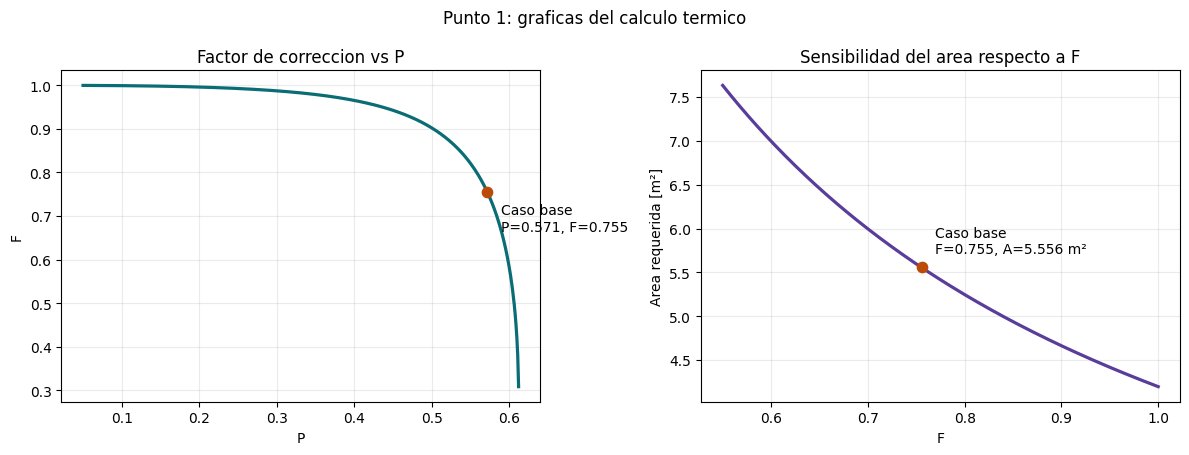

In [3]:
P_candidates = np.linspace(0.05, 1.0 / R - 1e-4, 600)
P_vals = []
F_vals = []

for p in P_candidates:
    base = (1.0 - p * R) / (1.0 - p)
    if base <= 0.0:
        continue
    Wp = math.exp((1.0 / Ns) * math.log(base))
    arg = (1.0 + Wp - S + S * Wp) / (1.0 + Wp + S - S * Wp)
    if arg <= 0.0 or abs(arg - 1.0) < 1e-12:
        continue
    Fp = S * math.log(Wp) / math.log(arg)
    if np.isfinite(Fp):
        P_vals.append(p)
        F_vals.append(Fp)

P_vals = np.array(P_vals)
F_vals = np.array(F_vals)
F_sens = np.linspace(0.55, 1.00, 300)
A_sens = Qdot / (U * F_sens * DTlm_cf)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

ax[0].plot(P_vals, F_vals, color='#0a6c74', linewidth=2.3)
ax[0].scatter([P], [F], color='#bc4b0a', s=55, zorder=3)
ax[0].annotate(f"Caso base\nP={P:.3f}, F={F:.3f}", (P, F), xytext=(10, -28), textcoords='offset points')
ax[0].set_xlabel('P')
ax[0].set_ylabel('F')
ax[0].set_title('Factor de correccion vs P')
ax[0].grid(True, alpha=0.25)

ax[1].plot(F_sens, A_sens, color='#5a3d9a', linewidth=2.3)
ax[1].scatter([F], [A], color='#bc4b0a', s=55, zorder=3)
ax[1].annotate(f"Caso base\nF={F:.3f}, A={A:.3f} m²", (F, A), xytext=(10, 10), textcoords='offset points')
ax[1].set_xlabel('F')
ax[1].set_ylabel('Area requerida [m²]')
ax[1].set_title('Sensibilidad del area respecto a F')
ax[1].grid(True, alpha=0.25)

fig.suptitle('Punto 1: graficas del calculo termico')
fig.tight_layout()
plt.show()


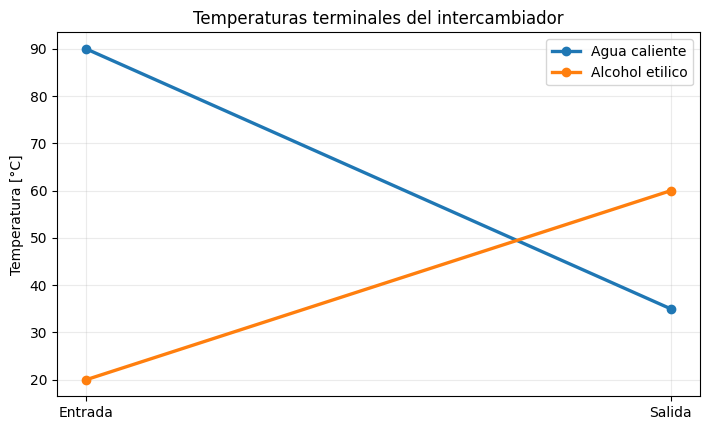

In [4]:
x = np.array([0.0, 1.0])
T_hot = np.array([Thi, Tho])
T_cold = np.array([Tci, Tco])

plt.figure(figsize=(7.2, 4.4))
plt.plot(x, T_hot, marker='o', linewidth=2.4, label='Agua caliente')
plt.plot(x, T_cold, marker='o', linewidth=2.4, label='Alcohol etilico')
plt.xticks([0, 1], ['Entrada', 'Salida'])
plt.ylabel('Temperatura [°C]')
plt.title('Temperaturas terminales del intercambiador')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
